<h2 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#800080; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">

    Weather Models for Rain Prediction in Australia

</h2>

<h6 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#F5F5F5; text-align:center; border-radius:5px 5px; padding:5px">

    Introduction

</h6>

This dataset contains detailed meteorological information recorded in Albury, Australia, for a specific period. It includes 24 attributes for each day, capturing various aspects of the weather. These attributes include:



- **Date**: The date of the weather observation.

- **Location**: The location where the observation was made.

- **MinTemp**: Minimum temperature of the day (in degrees Celsius).

- **MaxTemp**: Maximum temperature of the day (in degrees Celsius).

- **Rainfall**: Total rainfall recorded for the day (in millimeters).

- **Evaporation**: Total evaporation recorded for the day (in millimeters).

- **Sunshine**: Total hours of sunshine recorded for the day.

- **WindGustDir**: The direction of the strongest wind gust during the day.

- **WindGustSpeed**: The speed of the strongest wind gust during the day (in kilometers per hour).

- **WindDir9am**: The wind direction at 9 AM.

- **WindDir3pm**: The wind direction at 3 PM.

- **WindSpeed9am**: The wind speed at 9 AM (in kilometers per hour).

- **WindSpeed3pm**: The wind speed at 3 PM (in kilometers per hour).

- **Humidity9am**: The humidity level at 9 AM (percentage).

- **Humidity3pm**: The humidity level at 3 PM (percentage).

- **Pressure9am**: The atmospheric pressure at 9 AM (in hPa).

- **Pressure3pm**: The atmospheric pressure at 3 PM (in hPa).

- **Cloud9am**: The cloud cover at 9 AM (measured in oktas).

- **Cloud3pm**: The cloud cover at 3 PM (measured in oktas).

- **Temp9am**: The temperature at 9 AM (in degrees Celsius).

- **Temp3pm**: The temperature at 3 PM (in degrees Celsius).

- **RainToday**: Indicator of whether it rained today (Yes or No).

- **RISK_MM**: The amount of rain (in millimeters) recorded for the next day.

- **RainTomorrow**: Indicator of whether it rained the next day (Yes or No).



This dataset provides comprehensive insights into daily weather patterns and variations, aiding in climate analysis and prediction.

<h6 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#F5F5F5; text-align:center; border-radius:5px 5px; padding:5px">

    Objectives

</h6>

* Classify Whether It Will Rain Tomorrow

1. **Explore and Read the Dataset**:

   - Load the dataset and examine its structure and summary statistics.

   - Visualize the distribution and relationships of various features.



2. **Clean the Dataset**:

   - Handle missing values, outliers, and incorrect data entries.

   - Normalize or scale numerical features and encode categorical variables if necessary.



5. **Draw Conclusions**:

   - Interpret the findings and highlight the most effective models.

   - Provide insights into the important features that influence the likelihood of rain.

<h6 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#FFC0CB; color:#F5F5F5; text-align:center; border-radius:5px 5px; padding:5px">

    import libraries

</h6>

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt 

import seaborn as sns

In [2]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)


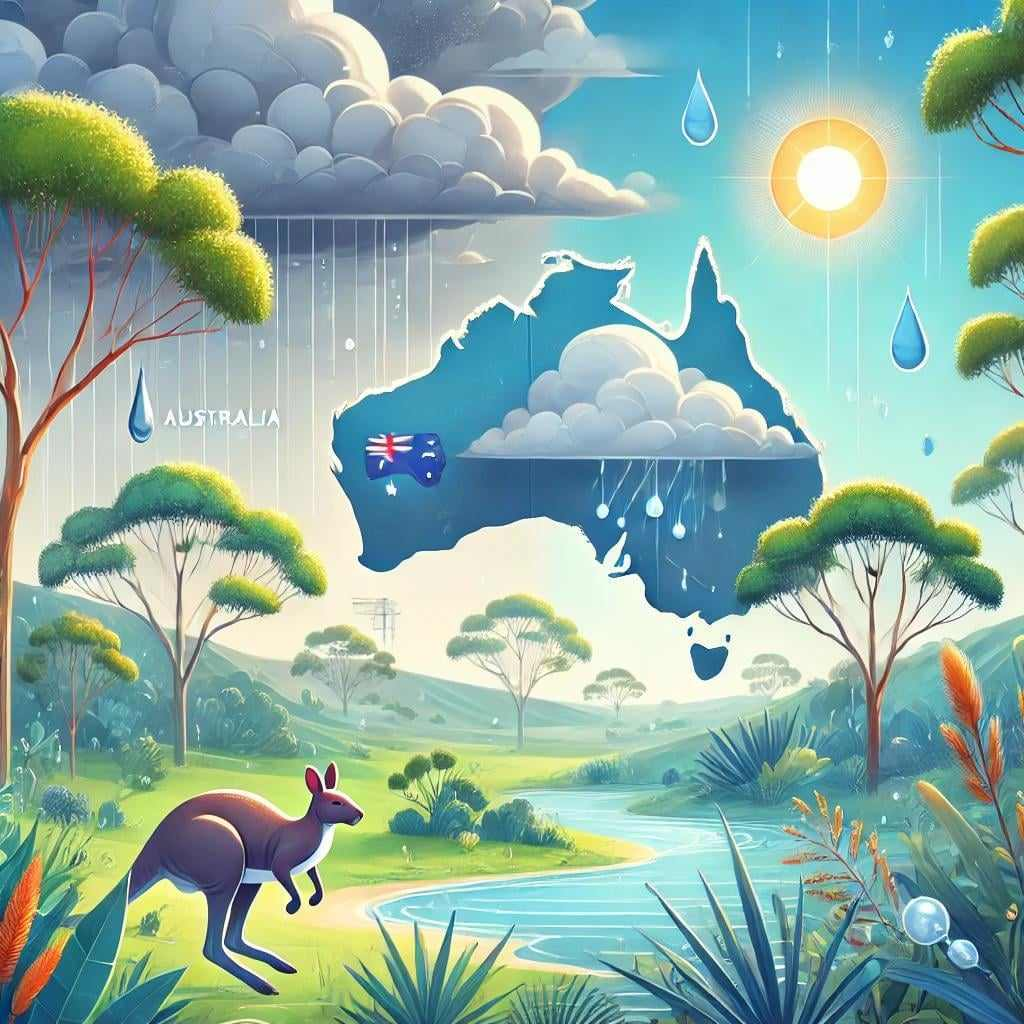

In [3]:
from IPython.display import Image

Image(filename='/kaggle/input/image-2/image (1).jpg',width=1000,height=200)

<h6 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#FFC0CB; color:#F5F5F5; text-align:center; border-radius:5px 5px; padding:5px">

    Load the data

</h6>

In [4]:
data=pd.read_csv('/kaggle/input/weatheraus/weatherAUS.csv')

data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,...,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,0.0,No
142189,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,0.0,No
142190,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,0.0,No
142191,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,0.0,No


<h6 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#FFC0CB; color:#F5F5F5; text-align:center; border-radius:5px 5px; padding:5px">

    Exploratory Data Analysis

</h6>

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

In [6]:
data.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')

In [7]:
data.isna().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

<h6 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#4CAF50; color:#F5F5F5; text-align:center; border-radius:5px 5px; padding:5px">

    Data Cleaning

</h6>

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">

    Missing Values

</h6>

In [8]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [9]:
data['Date'] = pd.to_datetime(data['Date'])

data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,...,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,0.0,No
142189,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,0.0,No
142190,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,0.0,No
142191,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,0.0,No


In [10]:
cleaned_weather_data = data.copy()



# Remove relative models from general values ​​(more than 30%)

high_missing_cols = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

cleaned_weather_data.drop(columns=high_missing_cols, inplace=True)

In [11]:
cleaned_weather_data.isna().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

In [12]:
# Remove rows that are missing key values ​​like 'MinTemp', 'MaxTemp', 'Rainfall'

cleaned_weather_data.dropna(subset=['MinTemp', 'MaxTemp', 'Rainfall'], inplace=True)

In [13]:
cleaned_weather_data.isna().sum()

Date                 0
Location             0
MinTemp              0
MaxTemp              0
Rainfall             0
WindGustDir       8614
WindGustSpeed     8558
WindDir9am        9322
WindDir3pm        3338
WindSpeed9am       842
WindSpeed3pm      2238
Humidity9am       1266
Humidity3pm       3164
Pressure9am      13305
Pressure3pm      13336
Temp9am            416
Temp3pm           2299
RainToday            0
RISK_MM              0
RainTomorrow         0
dtype: int64

In [14]:
cleaned_weather_data.shape  #142193 rows × 24 columns

(140086, 20)

In [15]:
# Fill missing values ​​in text columns with 'Unknown' and in numeric columns with median

categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

numerical_cols = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 

                  'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']



cleaned_weather_data[categorical_cols] = cleaned_weather_data[categorical_cols].fillna('Unknown')

cleaned_weather_data[numerical_cols] = cleaned_weather_data[numerical_cols].fillna(cleaned_weather_data[numerical_cols].median())

In [16]:
print(cleaned_weather_data.isnull().sum())

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RISK_MM          0
RainTomorrow     0
dtype: int64


In [17]:
from sklearn.impute import SimpleImputer

numerical_cols = cleaned_weather_data.select_dtypes(include=['float64']).columns

imputer = SimpleImputer(strategy='mean')

cleaned_weather_data[numerical_cols] = imputer.fit_transform(cleaned_weather_data[numerical_cols])

In [18]:
cleaned_weather_data.isna().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RISK_MM          0
RainTomorrow     0
dtype: int64

In [19]:
cleaned_weather_data.shape

(140086, 20)

In [20]:
cleaned_weather_data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,0.2,No


<h6 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#800080; color:#F5F5F5; text-align:center; border-radius:5px 5px; padding:5px">

    Visulaization

</h6>

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">

    Distribution of Minimum and Maximum Temperatures

</h6>

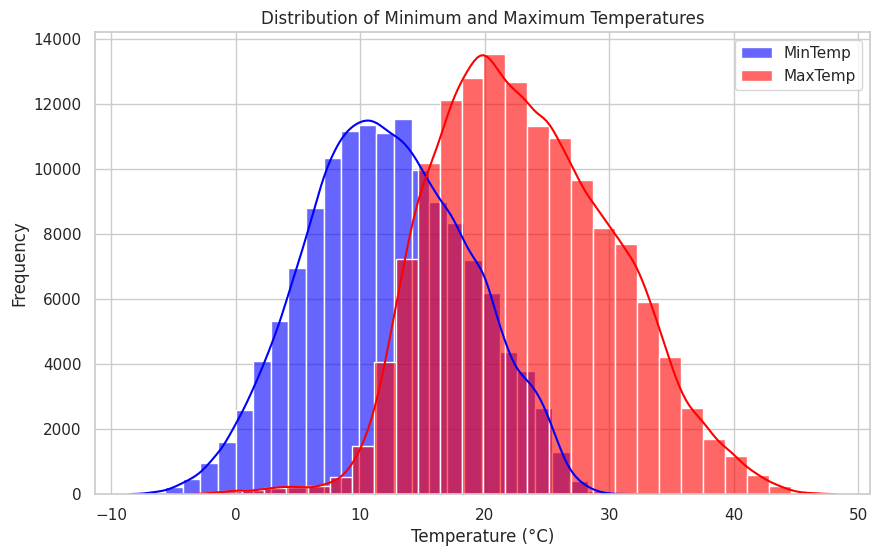

In [21]:
# Distribution of minimum and maximum temperatures:



# Setting the visualization mode

sns.set(style='whitegrid')



# Visualization 1: Distribution of MinTemp and MaxTemp

plt.figure(figsize=(10, 6))

sns.histplot(cleaned_weather_data['MinTemp'], bins=30, kde=True, color='blue', label='MinTemp', alpha=0.6)

sns.histplot(cleaned_weather_data['MaxTemp'], bins=30, kde=True, color='red', label='MaxTemp', alpha=0.6)

plt.title('Distribution of Minimum and Maximum Temperatures')

plt.xlabel('Temperature (°C)')

plt.ylabel('Frequency')

plt.legend()

plt.show()

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">

    Average rainfall by location

</h6>

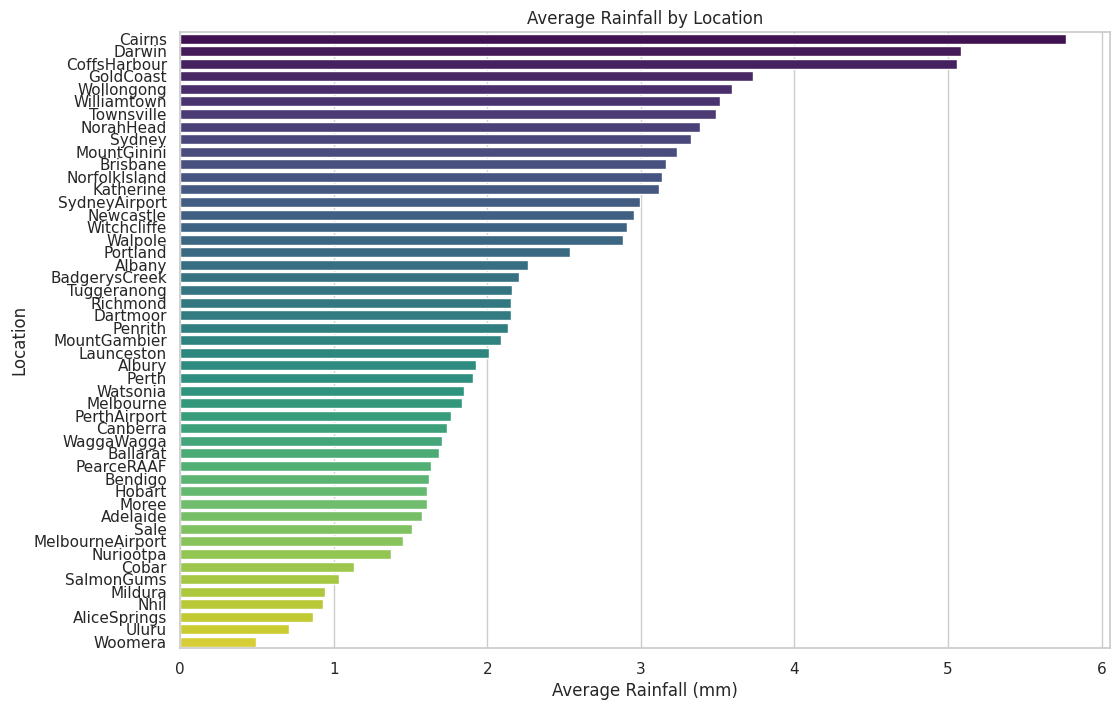

In [22]:
# Average rainfall by location:



plt.figure(figsize=(12, 8))

rainfall_by_location = cleaned_weather_data.groupby('Location')['Rainfall'].mean().sort_values(ascending=False)

sns.barplot(x=rainfall_by_location.values, y=rainfall_by_location.index, palette='viridis')

plt.title('Average Rainfall by Location')

plt.xlabel('Average Rainfall (mm)')

plt.ylabel('Location')

plt.show()




<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">

   Distribution of RainTomorrow

</h6>

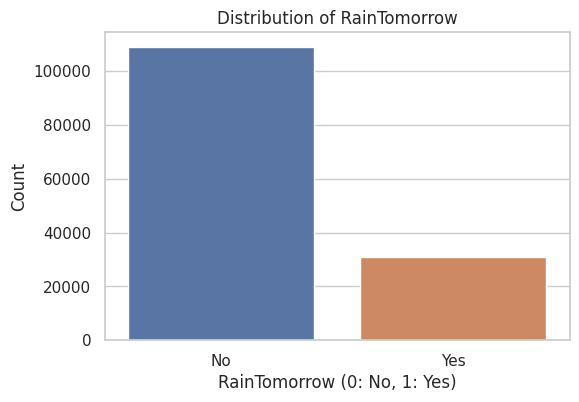

In [23]:
sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))

sns.countplot(x='RainTomorrow', data=cleaned_weather_data)

plt.title('Distribution of RainTomorrow')

plt.xlabel('RainTomorrow (0: No, 1: Yes)')

plt.ylabel('Count')

plt.show()

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">

   Correlation heatmap for numerical features

</h6>

<function matplotlib.pyplot.show(close=None, block=None)>

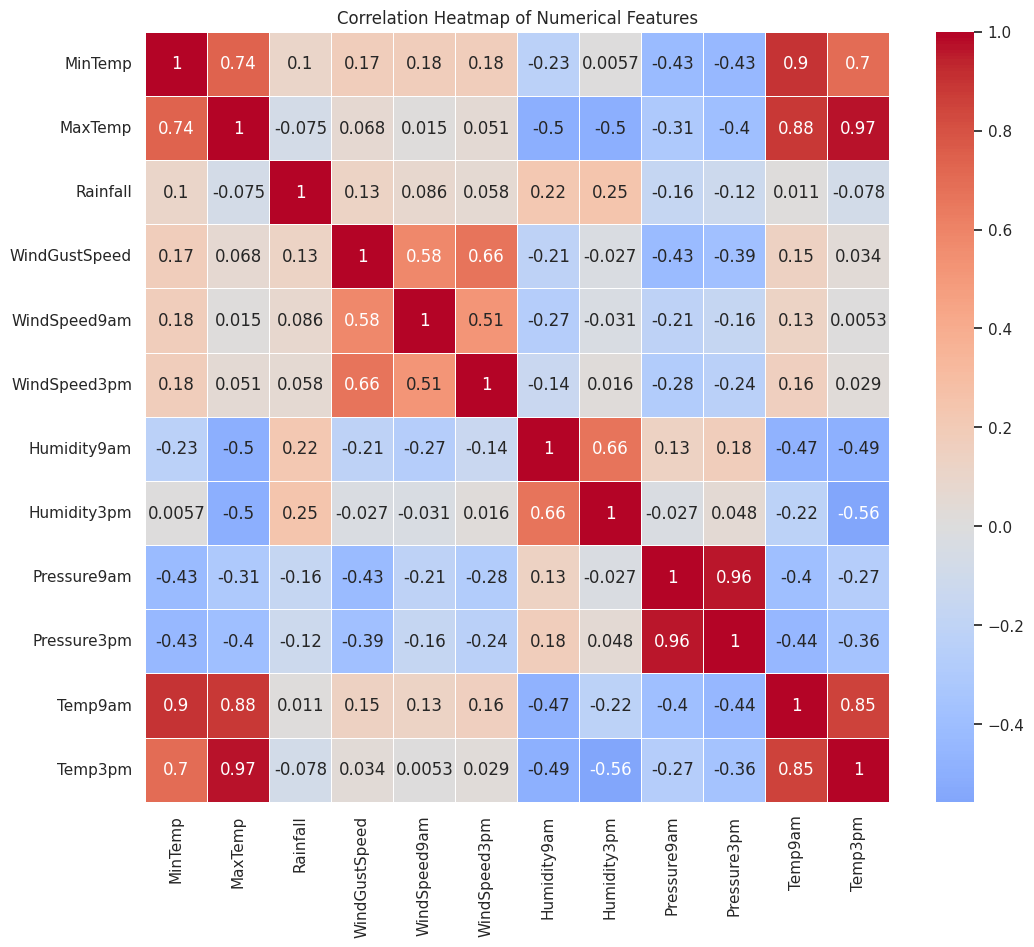

In [24]:
# Correlation heatmap for numerical features

plt.figure(figsize=(12, 10))

numerical_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 

                  'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

correlation_matrix = cleaned_weather_data[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')

plt.show

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">

   Max Temperature vs Humidity at 9 AM

</h6>

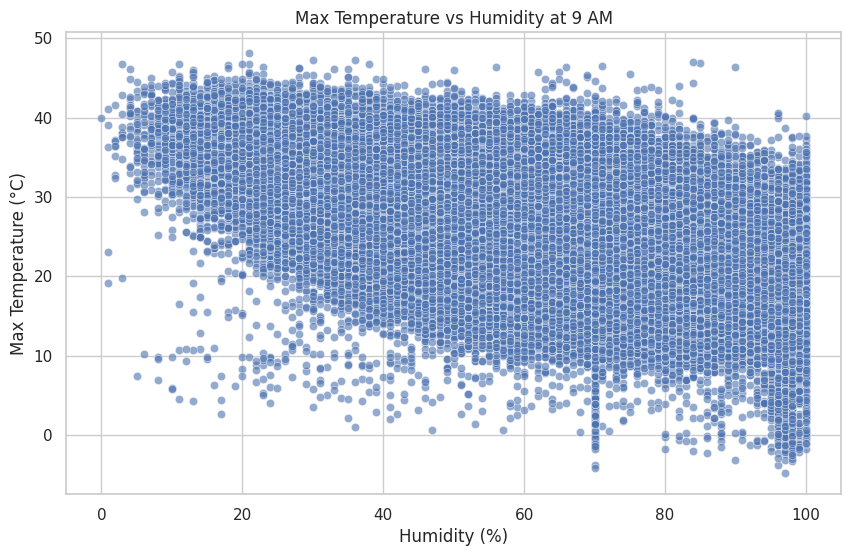

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='Humidity9am', y='MaxTemp', data=cleaned_weather_data, alpha=0.6)

plt.title('Max Temperature vs Humidity at 9 AM')

plt.xlabel('Humidity (%)')

plt.ylabel('Max Temperature (°C)')

plt.show()

<h6 style="font-size:25px; font-family:Garamond; font-weight:normal; background-color:#3E8E7E; color:#FFFFFF; text-align:center; border-radius:5px 5px; padding:5px">

  Max Temperature Distribution by Season

</h6>

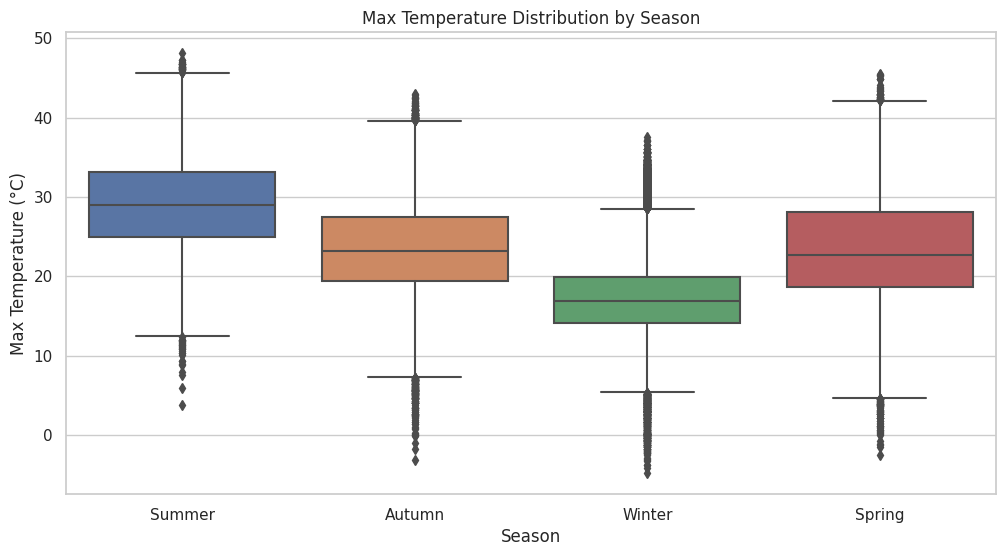

In [26]:
cleaned_weather_data['Season'] = pd.cut(cleaned_weather_data['Date'].dt.month, 

                                          bins=[0, 3, 6, 9, 12], 

                                          labels=['Summer', 'Autumn', 'Winter', 'Spring'], 

                                          right=False)

plt.figure(figsize=(12, 6))

sns.boxplot(x='Season', y='MaxTemp', data=cleaned_weather_data)

plt.title('Max Temperature Distribution by Season')

plt.ylabel('Max Temperature (°C)')

plt.xlabel('Season')

plt.show()